# Dubins Car Challenge
DD2410 — Planning Assignment <br/>
Chris Sprague <br/>
sprague@kth.se

# Description

In this assignment you're tasked to implement a robotic planning method to drive a Dubins car with the dynamics
$$
\left[
\begin{matrix}
\frac{dx}{dt} \\
\frac{dy}{dt} \\
\frac{d\theta}{dt} \\
\end{matrix}\right]
=
\left[
\begin{matrix}
\cos \theta \\
\sin \theta \\
\tan \phi(t)
\end{matrix}
\right]
$$
from an initial position $(x_0, y_0)$ to a target position $(x_f, y_f)$, while avoiding collisions with obstacles and going out of bounds.

## Variables
The state variables are
\begin{matrix}
x & = & \text{horizontal position} \\
y & = & \text{vertical position} \\
\theta & = & \text{heading position}
\end{matrix}
and the control is
$$
\phi(t) = [-\pi/4, \pi/4] = \text{steering angle}.
$$

# Tasks

We'll consider two graded tasks in order of difficulty:
 - **E** — reach the target with circular obstacles;
 - **C** — reach the target with line obstacles.
 
**Note**:
- the line obstacles are represented by a series of circular obstacles,
- the initial and target positions are randomised,
- and the obstacle in Kattis are different.

# Your solution file
Using the API (see `README.md`) and a robotic planning method, generate a sequence of steering angle commands `controls` and a sequence of times `times`, between which the commands are executed, that would yield a collision-free and task-fulfilling trajectory.

Do this by editing the function `solution(car)` contained in the file `solution.py`. If needed, supporting code can be added outside the `solution(car)` function.

The template solution looks like this:

```python
def solution(car):

    ''' <<< write your code below >>> '''
    controls=[0]
    times=[0,1]

    ''' <<< write your code above >>> '''

    return controls, times
```

## The solution function
The solution function `solution(car)` recieves a `Car` instance `car` and returns a tuple containing
 - `controls : list`: sequence of steering angles `controls[i] : float`
 - `times : list`: sequence of times at which the controls are executed `times[i] : float`

**Note**: `controls[i]` is considered to be constant between `times[i]` and `times[i+1]`, hence `len(controls) == len(times) - 1`.

## The `Car` object
The `Car` object has several attributes which you may find useful, namely:
 - `x0 : float`: initial x-position
 - `y0 : float`: initial y-position
 - `xt : float`: target x-position
 - `yt : float`: target y-position
 - `xlb : float`: minimum x-position
 - `xub : float`: maximum x-position
 - `ylb : float`: minimum y-position
 - `yub : float`: maximum y-position
 - `obs : list`: list of tuples for each obstacle `obs[i]`, where:
   - `obs[i][0] : float`: x-position
   - `obs[i][1] : float`: y-position
   - `obs[i][2] : float`: radius

**Note**: these attributes should not be edited.

In [6]:
from dubins import Car
car = Car()
print(car.__dict__)

{'_environment': <dubins.Environment object at 0x10dc16300>, 'x0': 0.0, 'y0': 8.78604010126979, 'xt': 20.0, 'yt': 3.789666484614373, 'obs': [(13.263887583950918, 8.791710572315933, 0.6260736974056679), (8.848468291538897, 4.124259192081675, 0.6759059917937946), (14.388109358328622, 1.9023719661697744, 0.5029088971977259), (5.3603325438975835, 7.857453677982067, 0.7885049570460735), (11.30122941253307, 4.504482707685091, 0.7185042674823314), (11.903838188980775, 6.657263335670918, 0.5016905231898013), (9.711916447757016, 1.9588951303386055, 0.6128099545358585), (6.7108204318658125, 1.1015169934462818, 0.7428914772014685), (11.425028784538974, 0.6293046555543725, 0.5258768498014946), (14.958342733138478, 5.531899560709547, 0.7958243686556727), (6.120498415419225, 3.9845885309187414, 0.6721691851107138), (8.085977808036644, 6.343945243883406, 0.5734700360062529), (9.19688888850975, 8.547595160152397, 0.5546642706251963), (15.41886227979576, 8.868373640985384, 0.5301453711540074), (4.73240

## The `step` function
The method that you'll need to utilise in your implementation of robotic planning methods is `step(car, x, y, theta, phi)` (imported from `dubins`), which takes as its arguments:
 - `car : Car`: instance of `Car`
 - `x : float`: x-position
 - `y : float`: y-position
 - `theta : float`: heading angle
 - `phi : float`: steering angle
 - `dt=0.01: float`: time-step size

and returns a tuple of the form `(xn, yn, thetan)` after `dt` seconds, containing:
 - `xn : float`: new x-position
 - `yn : float`: new y-position
 - `thetan : float`: new heading angle

**Note**: `dt` should not be below 0.01s.

After computing the new state `xn, yn, thetan = step(car, x, y, theta, phi)`, check `car.obs` to see if the new state is within any obstacles, `(car.xlb, car.xub, car.ylb, car.yub)` to see if it is out of bounds, and `(car.xt, car.yt)` to see if it is close the the target state.

## Taking a single step

In [7]:
from dubins import step

# arbitrary heading and steering angle
theta, phi = 0.0, 0.1

# take a step
step(car, car.x0, car.y0, theta, phi, dt=0.1)

(0.1, 8.78604010126979, 0.010033467208545055)

## Recording multiple steps

In [8]:
# trajectory: x, y, theta, phi, time
xl, yl, thetal, phil, tl = [car.x0], [car.y0], [0.0], [], [0.0]

# simulate for 1 seconds (10 * 0.1s = 1s) with constant steering angle phi = 0.1
phi = 0.1
for _ in range(10):
    xn, yn, thetan = step(car, xl[-1], yl[-1], thetal[-1], phi, dt=0.1)
    xl.append(xn)
    yl.append(yn)
    thetal.append(thetan)
    phil.append(phi)
    tl.append(tl[-1] + 0.1)

print('The state after 10s is (x={:.3f}, y={:.3f}, theta={:.3f})'.format(
    xl[-1], yl[-1], thetal[-1]
))
print('The controls and times were:\n phi={} \n t={}'.format(phil, tl))

The state after 10s is (x=0.999, y=8.831, theta=0.100)
The controls and times were:
 phi=[0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1] 
 t=[0.0, 0.1, 0.2, 0.30000000000000004, 0.4, 0.5, 0.6, 0.7, 0.7999999999999999, 0.8999999999999999, 0.9999999999999999]


# Creating a solution

In [ ]:
def solution(car):

    # trajectory: x, y, theta, phi, time
    x, y = car.x0, car.y0
    xl, yl, thetal, phil, tl = [x], [y], [0.0], [], [0.0]

    # simulate for 10 seconds with constant steering angle
    phi = -0.2
    for _ in range(2000):
        xn, yn, thetan = step(car, xl[-1], yl[-1], thetal[-1], phi, dt=0.1)
        xl.append(xn)
        yl.append(yn)
        thetal.append(thetan)
        phil.append(phi)
        tl.append(tl[-1] + 0.1)

    # return controls and times
    return phil, tl

In [33]:
from math import atan2, cos, sin, pi, hypot

def wrap_to_pi(a):
    while a <= -pi:
        a += 2*pi
    while a > pi:
        a -= 2*pi
    return a

def clamp(v, lo, hi):
    return lo if v < lo else hi if v > hi else v

def solution(car):
    env = car._environment

    # ----------------------------
    # 1) Grid + obstacle inflation
    # ----------------------------
    res = 0.25  # grid resolution [m] (smaller = better but slower)
    nx = int(env.lx / res) + 1
    ny = int(env.ly / res) + 1

    # Inflate obstacles by margin so we don't skim them
    margin = 0.45  # [m]
    inflated = [(ox, oy, r + margin) for (ox, oy, r) in car.obs]

    def inbounds_xy(x, y):
        return (0.0 <= x <= env.lx) and (0.0 <= y <= env.ly)

    def safe_xy(x, y):
        if not inbounds_xy(x, y):
            return False
        for (ox, oy, rr) in inflated:
            if hypot(x - ox, y - oy) <= rr:
                return False
        return True

    # Transforms between world coordinates and grid cell indices
    def to_cell(x, y):
        ix = int(round(x / res))
        iy = int(round(y / res))
        ix = max(0, min(nx - 1, ix))
        iy = max(0, min(ny - 1, iy))
        return ix, iy

    # Transform from grid cell indices to world coordinates (cell center)
    def to_xy(ix, iy):
        return ix * res, iy * res

    # start/goal
    sx, sy = car.x0, car.y0
    gx, gy = car.xt, car.yt

    start = to_cell(sx, sy) # transform start pos to grid coordinates
    goal = to_cell(gx, gy) # transform goal pos to grid coordinates

    # Precompute occupancy (optional but speeds checks)
    occ = [[False] * ny for _ in range(nx)] # False = free, True = occupied
    for ix in range(nx):
        x, _ = to_xy(ix, 0) # transform x to world coordinates
        for iy in range(ny):
            _, y = to_xy(0, iy) # transform y to world coordinates
            if not safe_xy(x, y):
                occ[ix][iy] = True
            else:
                occ[ix][iy] = False

    # ----------------------------
    # 2) A* path planning on grid
    # ----------------------------
    # 8-connected neighbors
    nbrs = [(-1, 0), (1, 0), (0, -1), (0, 1),
            (-1, -1), (-1, 1), (1, -1), (1, 1)]

    def h(c): # heuristic function for A*, c is a cell (ix, iy) in grid coordinates
        # Euclidean heuristic in grid coordinates
        d = ((c[0] - goal[0])**2 + (c[1] - goal[1])**2)**0.5 
        return d # hypot(c[0] - goal[0], c[1] - goal[1])

    # A* without heap (good enough for this grid size)
    INF = 10**18
    gscore = [[INF] * ny for _ in range(nx)] # gscore[ix][iy] = best known cost to reach cell (ix, iy)
    parent = [[None] * ny for _ in range(nx)] # parent[ix][iy] = previous cell on best path to (ix, iy)
    
    open_set = {start}
    closed = set()

    gscore[start[0]][start[1]] = 0.0

    def best_in_open():
        best = None
        bestf = INF
        for c in open_set:
            gs = gscore[c[0]][c[1]]
            # A* is f = g + h:
            # f = gs + h(c)
            # Dijkstra's would be the same but without the heuristic: f = gs:
            f = gs
            if f < bestf:
                bestf = f
                best = c
        return best

    found = False
    # Limit expansions to avoid worst-case runaway
    for _ in range(nx * ny):
        if not open_set:
            break
        current = best_in_open()
        if current == goal:
            found = True
            break
        open_set.remove(current)
        closed.add(current)

        cx, cy = current
        for dx, dy in nbrs:
            nx2, ny2 = cx + dx, cy + dy
            if nx2 < 0 or nx2 >= nx or ny2 < 0 or ny2 >= ny:
                continue
            if occ[nx2][ny2]:
                continue
            neigh = (nx2, ny2)
            if neigh in closed:
                continue
            step_cost = hypot(dx, dy)
            tentative = gscore[cx][cy] + step_cost
            if tentative < gscore[nx2][ny2]:
                gscore[nx2][ny2] = tentative
                parent[nx2][ny2] = current
                open_set.add(neigh)

    # If A* failed, fall back to straight-line steering (better than nothing)
    if not found:
        return _fallback_goto(car, dt=0.01)

    # Reconstruct path (cells)
    path_cells = []
    cur = goal
    while cur is not None:
        path_cells.append(cur)
        cur = parent[cur[0]][cur[1]]
    path_cells.reverse()

    # Convert to waypoints (x,y)
    waypoints = [to_xy(ix, iy) for (ix, iy) in path_cells]

    # ----------------------------
    # 3) Path shortcut smoothing
    # ----------------------------
    def line_safe(a, b, step=0.05):
        ax, ay = a
        bx, by = b
        dist = hypot(bx - ax, by - ay)
        if dist < 1e-9:
            return safe_xy(ax, ay)
        n = max(2, int(dist / step))
        for i in range(n + 1):
            t = i / n
            x = ax + t * (bx - ax)
            y = ay + t * (by - ay)
            if not safe_xy(x, y):
                return False
        return True

    smoothed = []
    i = 0
    while i < len(waypoints):
        smoothed.append(waypoints[i])
        # jump as far as possible with line-of-sight
        j = len(waypoints) - 1
        while j > i + 1:
            if line_safe(waypoints[i], waypoints[j]):
                break
            j -= 1
        i = j if j > i else i + 1

    # Ensure final waypoint is goal-ish
    if smoothed[-1] != (gx, gy):
        smoothed.append((gx, gy))

    # ----------------------------
    # 4) Track waypoints with steering control
    # ----------------------------
    # Dubins car: xdot=cos(theta), ydot=sin(theta), thetadot=tan(phi)
    # We'll use a lookahead target and choose phi to reduce heading error.
    dt = 0.01
    t = 0.0
    t_max = 80.0
    max_phi = pi / 4

    # Controller knobs
    lookahead = 0.9     # [m]
    k_heading = 1.6     # heading gain
    waypoint_tol = 0.6  # [m]

    x, y, theta = car.x0, car.y0, 0.0
    controls = []
    times = [0.0]

    def done_xy(x, y):
        return hypot(car.xt - x, car.yt - y) < 1.5

    wi = 0
    # start from nearest waypoint index (helps if start cell center differs)
    besti = 0
    bestd = 1e9
    for idx, (wx, wy) in enumerate(smoothed):
        d = hypot(wx - x, wy - y)
        if d < bestd:
            bestd = d
            besti = idx
    wi = besti

    while t < t_max and not done_xy(x, y):
        # advance waypoint if close
        while wi < len(smoothed) - 1 and hypot(smoothed[wi][0] - x, smoothed[wi][1] - y) < waypoint_tol:
            wi += 1

        # pick a lookahead point further along the path
        target = smoothed[wi]
        # if target is too close, try pushing forward
        if hypot(target[0] - x, target[1] - y) < lookahead and wi < len(smoothed) - 1:
            # find first waypoint at least lookahead away
            for j in range(wi, len(smoothed)):
                if hypot(smoothed[j][0] - x, smoothed[j][1] - y) >= lookahead:
                    target = smoothed[j]
                    wi = j
                    break

        tx, ty = target
        ang = atan2(ty - y, tx - x)
        err = wrap_to_pi(ang - theta)

        phi = clamp(k_heading * err, -max_phi, max_phi)

        # take one step
        xn, yn, thetan = step(car, x, y, theta, phi, dt=dt)

        # if stepping would collide, try a short “wiggle” to recover
        if not env.safe(xn, yn):
            recovered = False
            for escape_phi in (max_phi, -max_phi, max_phi*0.6, -max_phi*0.6):
                ex, ey, et = step(car, x, y, theta, escape_phi, dt=dt)
                if env.safe(ex, ey):
                    phi = escape_phi
                    xn, yn, thetan = ex, ey, et
                    recovered = True
                    break
            if not recovered:
                break

        controls.append(phi)
        t += dt
        times.append(t)
        x, y, theta = xn, yn, thetan

    return controls, times

def _fallback_goto(car, dt=0.01):
    # Very simple fallback: steer toward goal (no obstacle avoidance).
    # Only used if A* fails.
    from math import atan2, hypot, pi
    def wrap_to_pi(a):
        while a <= -pi:
            a += 2*pi
        while a > pi:
            a -= 2*pi
        return a
    def clamp(v, lo, hi):
        return lo if v < lo else hi if v > hi else v

    x, y, theta = car.x0, car.y0, 0.0
    t = 0.0
    t_max = 60.0
    max_phi = pi/4
    k = 1.6

    controls = []
    times = [0.0]
    while t < t_max and hypot(car.xt - x, car.yt - y) >= 1.5:
        ang = atan2(car.yt - y, car.xt - x)
        err = wrap_to_pi(ang - theta)
        phi = clamp(k * err, -max_phi, max_phi)
        xn, yn, thetan = step(car, x, y, theta, phi, dt=dt)
        if not car._environment.safe(xn, yn):
            break
        controls.append(phi)
        t += dt
        times.append(t)
        x, y, theta = xn, yn, thetan
    return controls, times

In [41]:
import heapq
from math import atan2, atan, cos, sin, pi, hypot

def astar(start, goal, occ, nx, ny):
    # occ(ix,iy) -> True if blocked
    nbrs = [(-1,0),(1,0),(0,-1),(0,1),(-1,-1),(-1,1),(1,-1),(1,1)]

    def h(a, b):
        return hypot(a[0]-b[0], a[1]-b[1])

    openh = [(h(start, goal), 0.0, start)]  # (f, g, node)
    came = {start: None}
    gscore = {start: 0.0}
    seen = set()

    while openh:
        _, g, cur = heapq.heappop(openh)
        if cur in seen:
            continue
        seen.add(cur)

        if cur == goal:
            path = []
            while cur is not None:
                path.append(cur)
                cur = came[cur]
            return path[::-1]

        cx, cy = cur
        for dx, dy in nbrs:
            nx2, ny2 = cx + dx, cy + dy
            if not (0 <= nx2 < nx and 0 <= ny2 < ny):
                continue
            if occ[nx2][ny2]:
                continue
            nxt = (nx2, ny2)
            ng = g + hypot(dx, dy)
            if ng < gscore.get(nxt, 1e18):
                gscore[nxt] = ng
                came[nxt] = cur
                heapq.heappush(openh, (ng + h(nxt, goal), ng, nxt))

    return None

def wrap_to_pi(a):
    while a <= -pi: a += 2*pi
    while a > pi: a -= 2*pi
    return a

def clamp(v, lo, hi):
    return lo if v < lo else hi if v > hi else v

waypoint_tol = 0.5 # when "close enough" to advance
def pure_pursuit_control(x, y, theta, waypoints, i, Ld, max_phi):
    # advance waypoint index if we're close
    while i < len(waypoints)-1 and hypot(waypoints[i][0]-x, waypoints[i][1]-y) < waypoint_tol:
        i += 1

    # choose a target at least Ld away (walk forward along waypoints)
    j = i
    while j < len(waypoints)-1 and hypot(waypoints[j][0]-x, waypoints[j][1]-y) < Ld:
        j += 1
    tx, ty = waypoints[j]

    alpha = wrap_to_pi(atan2(ty - y, tx - x) - theta)
    kappa = 2.0 * sin(alpha) / max(Ld, 1e-6)
    phi = clamp(atan(kappa), -max_phi, max_phi)
    return phi, i



def solution(car):
    env = car._environment

    # ----------------------------
    # 1) Grid + obstacle inflation
    # ----------------------------
    res = 0.25  # grid resolution [m] (smaller = better but slower)
    nx = int(env.lx / res) + 1
    ny = int(env.ly / res) + 1

    # Inflate obstacles by margin so we don't skim them
    margin = 0.45  # [m]
    inflated = [(ox, oy, r + margin) for (ox, oy, r) in car.obs]

    def inbounds_xy(x, y):
        return (0.0 <= x <= env.lx) and (0.0 <= y <= env.ly)

    def safe_xy(x, y):
        if not inbounds_xy(x, y):
            return False
        for (ox, oy, rr) in inflated:
            if hypot(x - ox, y - oy) <= rr:
                return False
        return True

    # Transforms between world coordinates and grid cell indices
    def to_cell(x, y):
        ix = int(round(x / res))
        iy = int(round(y / res))
        ix = max(0, min(nx - 1, ix))
        iy = max(0, min(ny - 1, iy))
        return ix, iy

    # Transform from grid cell indices to world coordinates (cell center)
    def to_xy(ix, iy):
        return ix * res, iy * res

    # start/goal
    sx, sy = car.x0, car.y0
    gx, gy = car.xt, car.yt

    start = to_cell(sx, sy) # transform start pos to grid coordinates
    goal = to_cell(gx, gy) # transform goal pos to grid coordinates

    # Precompute occupancy (optional but speeds checks)
    occ = [[False] * ny for _ in range(nx)] # False = free, True = occupied
    for ix in range(nx):
        x, _ = to_xy(ix, 0) # transform x to world coordinates
        for iy in range(ny):
            _, y = to_xy(0, iy) # transform y to world coordinates
            if not safe_xy(x, y):
                occ[ix][iy] = True
            else:
                occ[ix][iy] = False
                
                
    cells = astar(start, goal, occ, nx, ny)
    waypoints = [to_xy(ix, iy) for (ix, iy) in cells]
    
        # ---------- 4) Pure pursuit tracking ----------
    dt = 0.01
    max_phi = pi / 4
    Ld = 1.0                 # lookahead distance
    t_max = 80.0

    x, y, theta = car.x0, car.y0, 0.0
    t = 0.0
    controls = []
    times = [0.0]

    def done_xy(x, y):
        return hypot(car.xt - x, car.yt - y) < 1.5
    
    i = 0 # waypoint index
    while not done_xy(x, y) and t < t_max:
        phi, i = pure_pursuit_control(x, y, theta, waypoints, i, Ld, max_phi)
        x, y, theta = step(car, x, y, theta, phi, dt=0.01)
        controls.append(phi)
        times.append(times[-1] + dt)
        
    return controls, times

In [69]:
from math import atan2, atan, sin, pi, hypot
import heapq
from dubins import *   # provides step(), Car/Environment in your setup

def solution(car):
    # ---------- small helpers ----------
    def wrap_to_pi(a):
        while a <= -pi: a += 2*pi
        while a >  pi: a -= 2*pi
        return a

    def clamp(v, lo, hi):
        return lo if v < lo else hi if v > hi else v

    # ---------- 1) Build inflated occupancy grid ----------
    env = car._environment
    res = 0.25               # grid resolution (smaller -> better but slower)
    margin = 0.55            # inflate obstacles by this much (helps prevent clipping)
    inflated = [(ox, oy, r + margin) for (ox, oy, r) in car.obs]

    nx = int(env.lx / res) + 1
    ny = int(env.ly / res) + 1

    def safe_inflated(x, y):
        if x < 0 or x > env.lx or y < 0 or y > env.ly:
            return False
        for (ox, oy, rr) in inflated:
            if hypot(x - ox, y - oy) <= rr:
                return False
        return True

    def to_cell(x, y):
        ix = int(round(x / res))
        iy = int(round(y / res))
        return max(0, min(nx - 1, ix)), max(0, min(ny - 1, iy))

    def to_xy(ix, iy):
        return ix * res, iy * res

    # Precompute blocked cells
    occ = [[False] * ny for _ in range(nx)]
    for ix in range(nx):
        x = ix * res
        for iy in range(ny):
            y = iy * res
            occ[ix][iy] = not safe_inflated(x, y)

    start = to_cell(car.x0, car.y0)
    goal  = to_cell(car.xt, car.yt)

    # ---------- 2) A* on grid ----------
    def astar(start, goal):
        nbrs = [(-1,0),(1,0),(0,-1),(0,1),(-1,-1),(-1,1),(1,-1),(1,1)]
        def h(a, b): return hypot(a[0]-b[0], a[1]-b[1])

        openh = [(h(start, goal), 0.0, start)]   # (f, g, node)
        came  = {start: None}
        gbest  = {start: 0.0}
        seen  = set()

        while openh:
            _, g, cur = heapq.heappop(openh)
            if cur in seen:
                continue
            seen.add(cur)

            if cur == goal:
                path = []
                while cur is not None:
                    path.append(cur)
                    cur = came[cur]
                return path[::-1]

            cx, cy = cur
            for dx, dy in nbrs:
                nx2, ny2 = cx + dx, cy + dy
                if not (0 <= nx2 < nx and 0 <= ny2 < ny):
                    continue
                if occ[nx2][ny2]:
                    continue
                nxt = (nx2, ny2)
                ng = g + hypot(dx, dy)
                if ng < gbest.get(nxt, 1e18):
                    gbest[nxt] = ng
                    came[nxt] = cur
                    heapq.heappush(openh, (ng + h(nxt, goal), ng, nxt))
        return None

    cells = astar(start, goal)
    waypoints = [to_xy(ix, iy) for (ix, iy) in cells]

    # ---------- 4) Pure pursuit tracking ----------
    dt = 0.01
    max_phi = pi / 4
    Ld = 1.0                 # lookahead distance
    waypoint_tol = 0.5        # when "close enough" to advance
    t_max = 80.0

    x, y, theta = car.x0, car.y0, 0.0
    t = 0.0
    controls = []
    times = [0.0]

    wi = 0  # waypoint index

    def done_xy(x, y):
        return hypot(car.xt - x, car.yt - y) < 1.5

    while t < t_max and not done_xy(x, y):
        # advance index if close
        while wi < len(waypoints) - 1 and hypot(waypoints[wi][0]-x, waypoints[wi][1]-y) < waypoint_tol:
            wi += 1

        # choose a target at least Ld away
        tj = wi
        while tj < len(waypoints) - 1 and hypot(waypoints[tj][0]-x, waypoints[tj][1]-y) < Ld:
            tj += 1
        tx, ty = waypoints[tj]

        alpha = wrap_to_pi(atan2(ty - y, tx - x) - theta)
        kappa = 2.0 * sin(alpha) / max(Ld, 1e-6)
        phi = clamp(atan(kappa), -max_phi, max_phi)

        xn, yn, thetan = step(car, x, y, theta, phi, dt=dt)

        controls.append(phi)
        t += dt
        times.append(t)
        x, y, theta = xn, yn, thetan

    return controls, times

In [95]:
from math import atan2, atan, sin, pi
import heapq
from dubins import *  # provides step()

def wrap_to_pi(a):
    while a <= -pi:
        a += 2*pi
    while a > pi:
        a -= 2*pi
    return a

def clamp(v, lo, hi):
    return lo if v < lo else hi if v > hi else v

def euclidean_norm(dx, dy): # magnitude of vector (dx, dy)
    return (dx**2 + dy**2)**0.5

def euclidean_distance_between_points(x1, y1, x2, y2):
    return ((x2 - x1)**2 + (y2 - y1)**2)**0.5

# A* planner:
def astar_path_planner(start, goal, occ_grid, nx, ny):
    """
    A* on an 8-connected grid.

    start, goal: (ix, iy)
    occ: 2D boolean grid where occ[ix][iy] == True means occupied
    nx, ny: grid dimensions

    Returns: list of cells [(ix,iy), ...] or None
    """
    neighbours = [(-1,0),(1,0),(0,-1),(0,1),(-1,-1),(-1,1),(1,-1),(1,1)]

    def heuristic(a, b): # based on Euclidean distance in grid coordinates
        return euclidean_distance_between_points(a[0], a[1], b[0], b[1])

    openh = [(heuristic(start, goal), 0.0, start)]  # (f, g, node) open heap
    came  = {start: None} # best known parent for each cell
    gbest = {start: 0.0} # best known g score for each cell
    visited  = set() # closed set (visited cells)

    while openh:
        _, g, cur = heapq.heappop(openh)
        if cur in visited:
            continue
        visited.add(cur) # mark current cell as visited

        if cur == goal: # reconstruct path
            path = []
            while cur is not None:
                path.append(cur)
                cur = came[cur] # move backwards through parents to reconstruct path
            return path[::-1] # reverse path to get from start to goal

        cx, cy = cur
        for dx, dy in neighbours:
            nx2, ny2 = cx + dx, cy + dy
            if not (0 <= nx2 < nx and 0 <= ny2 < ny): # if cell is out of bounds, skip
                continue
            if occ_grid[nx2][ny2]: # if cell is occupied, skip
                continue

            nxt = (nx2, ny2) # neighbour cell
            ng = g + euclidean_norm(dx, dy) # cost to move to neighbour (neighbour g score)

            if ng < gbest.get(nxt, 1e18):
                gbest[nxt] = ng
                came[nxt] = cur
                heapq.heappush(openh, (ng + heuristic(nxt, goal), ng, nxt)) # push neighbour to open heap with f = g + h

    return None

# Pure pursuit tracker/controller:
def pure_pursuit_controller(car, waypoints, dt=0.01, Ld=1.0, waypoint_tol=0.5, t_max=80.0):
    """
    Tracks waypoints using pure pursuit.

    Returns: (controls, times)
    """
    max_phi = pi / 4

    # Initial state
    x, y, theta = car.x0, car.y0, 0.0
    t = 0.0
    controls = []
    times = [0.0]
    wi = 0

    def done_xy(x, y): # when we're close enough to the goal, we can stop
        return euclidean_distance_between_points(x, y, car.xt, car.yt) < 1.5

    while t < t_max and not done_xy(x, y):
        # advance index if close (checkpoint completed --> go to next checkpoint). "Did I reach this waypoint?"
        while wi < len(waypoints) - 1 and euclidean_distance_between_points(waypoints[wi][0], waypoints[wi][1], x, y) < waypoint_tol: # if we're close to the current waypoint, advance to the next one
            wi += 1

        # Pure Pursuit lookahead target selection: choose a target at least Ld away (aim further ahead so steering is smoother). "Where should I aim right now?"
        tj = wi
        while tj < len(waypoints) - 1 and euclidean_distance_between_points(waypoints[tj][0], waypoints[tj][1], x, y) < Ld: # if the current target is too close, try pushing forward to find a further target
            tj += 1
        tx, ty = waypoints[tj]

        heading_to_target = atan2(ty - y, tx - x)
        heading_err = wrap_to_pi(heading_to_target - theta) # heading error to target position. theta is the current heading of the car, so this is how much we need to turn to face the target
        kappa = 2.0 * sin(heading_err) / max(Ld, 1e-6) # curvature to reach target (pure pursuit control law)
        phi = clamp(atan(kappa), -max_phi, max_phi) # steering angle command (clamped to max_phi)

        x, y, theta = step(car, x, y, theta, phi, dt=dt)

        controls.append(phi)
        t += dt
        times.append(t)

    return controls, times


def solution(car):
    env = car._environment # 20x10 environment described by a rectangle [(0,0),(20,0),(20,10),(0,10)], containing n circular obstacles of radius r, positioned randomly within

    # Create occupancy grid representation + obstacle inflation
    res = 0.25 # grid resolution (smaller = better but slower)
    margin = 0.55 # inflate obstacles margin
    inflated = [(ox, oy, r + margin) for (ox, oy, r) in car.obs]

    nx = int(env.lx / res) + 1 # number of grid cells in x direction
    ny = int(env.ly / res) + 1 # number of grid cells in y direction

    def safe_inflated(x, y): # returns true (safe) if (x, y) is in bounds and not in collision with any inflated obstacle
        if x < 0 or x > env.lx or y < 0 or y > env.ly:
            return False
        for (ox, oy, rr) in inflated:
            if euclidean_distance_between_points(x, y, ox, oy) <= rr:
                return False
        return True

    def to_cell_coordinates(x, y): # to grid coordinates (ix, iy)
        ix = int(round(x / res))
        iy = int(round(y / res))
        return max(0, min(nx - 1, ix)), max(0, min(ny - 1, iy))

    def to_world_coordinates(ix, iy): # to world coordinates (x, y) at cell center
        return ix * res, iy * res

    # Build occupancy grid
    occ_grid = [[False] * ny for _ in range(nx)]
    for ix in range(nx):
        x = ix * res
        for iy in range(ny):
            y = iy * res
            if not safe_inflated(x, y):
                occ_grid[ix][iy] = True # occupied cell
            else:
                occ_grid[ix][iy] = False # free cell

    start = to_cell_coordinates(car.x0, car.y0) # transform start position to grid coordinates 
    goal  = to_cell_coordinates(car.xt, car.yt) # transform goal position to grid coordinates

    cells = astar_path_planner(start, goal, occ_grid, nx, ny) # plan path in grid coordinates (list of cells) using A*
    if cells is None:
        # fallback: no path found; return a minimal valid output
        return [0.0], [0.0, 0.01]

    waypoints = [to_world_coordinates(ix, iy) for (ix, iy) in cells] # convert path from grid coordinates to world coordinates (list of waypoints)

    controls, times = pure_pursuit_controller(car, waypoints, dt=0.01, Ld=1.0, waypoint_tol=0.5, t_max=80.0) # track waypoints with pure pursuit controller to get controls and times

    return controls, times

In [82]:
from math import atan2, atan, sin, pi, hypot
from random import random, uniform
from dubins import *  # provides step()

# ---------------- helpers ----------------
def wrap_to_pi(a):
    while a <= -pi:
        a += 2 * pi
    while a > pi:
        a -= 2 * pi
    return a

def clamp(v, lo, hi):
    return lo if v < lo else hi if v > hi else v

# ---------------- collision checking ----------------
def line_safe(a, b, safe_fn, step_len=0.05):
    ax, ay = a
    bx, by = b
    dist = hypot(bx - ax, by - ay)
    if dist < 1e-9:
        return safe_fn(ax, ay)
    n = max(2, int(dist / step_len))
    for k in range(n + 1):
        t = k / n
        x = ax + t * (bx - ax)
        y = ay + t * (by - ay)
        if not safe_fn(x, y):
            return False
    return True

# ---------------- RRT* planner (x,y only) ----------------
def rrt_star_plan(
    start, goal, safe_fn, bounds,
    iters=3500, eta=0.6, goal_sample_rate=0.15,
    near_radius=1.4, goal_tol=1.0, line_step=0.05
):
    """
    RRT* in (x,y). Returns a waypoint list [(x,y), ...] or None.
    bounds = (xlb, xub, ylb, yub)
    """
    xlb, xub, ylb, yub = bounds

    if not safe_fn(start[0], start[1]) or not safe_fn(goal[0], goal[1]):
        return None

    nodes = [start]
    parent = [-1]
    cost = [0.0]

    best_goal_idx = None
    best_goal_cost = float("inf")

    def sample():
        if random() < goal_sample_rate:
            return goal
        return (uniform(xlb, xub), uniform(ylb, yub))

    def nearest(q):
        bi, bd = 0, float("inf")
        for i, p in enumerate(nodes):
            d = hypot(p[0] - q[0], p[1] - q[1])
            if d < bd:
                bd = d
                bi = i
        return bi, bd

    def steer(p, q):
        px, py = p
        qx, qy = q
        d = hypot(qx - px, qy - py)
        if d <= eta:
            return (qx, qy)
        s = eta / max(d, 1e-9)
        return (px + s * (qx - px), py + s * (qy - py))

    def near_indices(qnew):
        out = []
        for i, p in enumerate(nodes):
            if hypot(p[0] - qnew[0], p[1] - qnew[1]) <= near_radius:
                out.append(i)
        return out

    for _ in range(iters):
        qrand = sample()
        i_near, _ = nearest(qrand)
        qnear = nodes[i_near]
        qnew = steer(qnear, qrand)

        if not safe_fn(qnew[0], qnew[1]):
            continue
        if not line_safe(qnear, qnew, safe_fn, step_len=line_step):
            continue

        # choose best parent among neighbors (RRT*)
        neighbors = near_indices(qnew)
        best_p = i_near
        best_c = cost[i_near] + hypot(qnew[0] - qnear[0], qnew[1] - qnear[1])

        for j in neighbors:
            pj = nodes[j]
            c = cost[j] + hypot(qnew[0] - pj[0], qnew[1] - pj[1])
            if c < best_c and line_safe(pj, qnew, safe_fn, step_len=line_step):
                best_c = c
                best_p = j

        # add node
        new_idx = len(nodes)
        nodes.append(qnew)
        parent.append(best_p)
        cost.append(best_c)

        # rewire neighbors
        for j in neighbors:
            if j == best_p:
                continue
            pj = nodes[j]
            new_cost = best_c + hypot(pj[0] - qnew[0], pj[1] - qnew[1])
            if new_cost < cost[j] and line_safe(qnew, pj, safe_fn, step_len=line_step):
                parent[j] = new_idx
                cost[j] = new_cost

        # check goal
        if hypot(qnew[0] - goal[0], qnew[1] - goal[1]) <= goal_tol:
            if best_c < best_goal_cost and line_safe(qnew, goal, safe_fn, step_len=line_step):
                best_goal_cost = best_c
                best_goal_idx = new_idx

    if best_goal_idx is None:
        return None

    # build path from best goal node, then append goal
    path = []
    cur = best_goal_idx
    while cur != -1:
        path.append(nodes[cur])
        cur = parent[cur]
    path.reverse()
    path.append(goal)
    return path

# ---------------- Pure pursuit tracker ----------------
def pure_pursuit_controls(car, waypoints, dt=0.01, Ld=1.0, waypoint_tol=0.5, t_max=80.0):
    max_phi = pi / 4
    x, y, theta = car.x0, car.y0, 0.0
    t = 0.0
    controls = []
    times = [0.0]
    wi = 0

    def done_xy(x, y):
        return hypot(car.xt - x, car.yt - y) < 1.5

    while t < t_max and not done_xy(x, y):
        while wi < len(waypoints) - 1 and hypot(waypoints[wi][0] - x, waypoints[wi][1] - y) < waypoint_tol:
            wi += 1

        tj = wi
        while tj < len(waypoints) - 1 and hypot(waypoints[tj][0] - x, waypoints[tj][1] - y) < Ld:
            tj += 1
        tx, ty = waypoints[tj]

        alpha = wrap_to_pi(atan2(ty - y, tx - x) - theta)
        kappa = 2.0 * sin(alpha) / max(Ld, 1e-6)
        phi = clamp(atan(kappa), -max_phi, max_phi)

        xn, yn, thetan = step(car, x, y, theta, phi, dt=dt)

        # basic safety guard: if next step unsafe, try a quick hard turn
        if not car._environment.safe(xn, yn):
            recovered = False
            for escape_phi in (max_phi, -max_phi, 0.6 * max_phi, -0.6 * max_phi):
                ex, ey, et = step(car, x, y, theta, escape_phi, dt=dt)
                if car._environment.safe(ex, ey):
                    phi = escape_phi
                    xn, yn, thetan = ex, ey, et
                    recovered = True
                    break
            if not recovered:
                break

        controls.append(phi)
        t += dt
        times.append(t)
        x, y, theta = xn, yn, thetan

    return controls, times

# ---------------- solution combines RRT* + smoothing + pure pursuit ----------------
def solution(car):
    env = car._environment

    # inflate obstacles to keep tracking safe
    margin = 0.6
    inflated = [(ox, oy, r + margin) for (ox, oy, r) in car.obs]

    def safe_inflated(x, y):
        if x < 0 or x > env.lx or y < 0 or y > env.ly:
            return False
        for (ox, oy, rr) in inflated:
            if hypot(x - ox, y - oy) <= rr:
                return False
        return True

    start = (car.x0, car.y0)
    goal = (car.xt, car.yt)
    bounds = (0.0, env.lx, 0.0, env.ly)

    path = rrt_star_plan(
        start, goal, safe_inflated, bounds,
        iters=3500, eta=0.65, goal_sample_rate=0.18,
        near_radius=1.5, goal_tol=1.0, line_step=0.05
    )

    if path is None:
        # fallback: minimal valid output (won't usually succeed in clutter)
        return [0.0], [0.0, 0.01]

    # track
    return pure_pursuit_controls(car, path, dt=0.01, Ld=1.0, waypoint_tol=0.5, t_max=80.0)

## Evaluating your solution

Grade E: 5/6 cases passed.
Grade C: 5/6 cases passed.


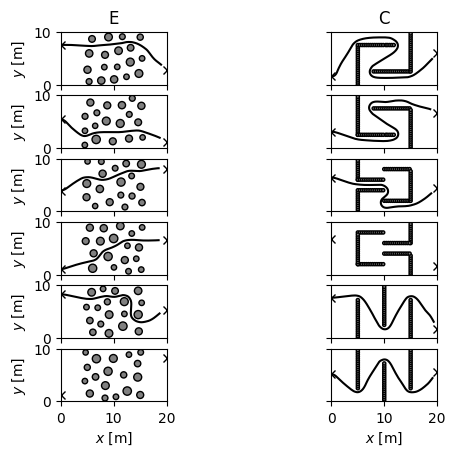

In [84]:
%matplotlib inline
from main import main
# using RRT* + pure pursuit tracking
main(solution, plot=True, verbose=False)

Grade E: 6/6 cases passed.
Grade C: 6/6 cases passed.


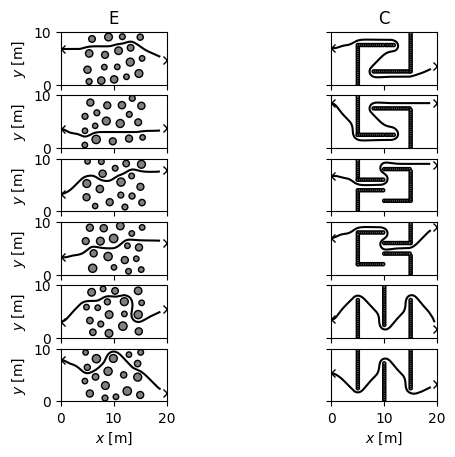

In [96]:
%matplotlib inline
from main import main
# Using A* + pure pursuit tracking
main(solution, plot=True, verbose=False)

Grade E: 6/6 cases passed.
Grade C: 6/6 cases passed.


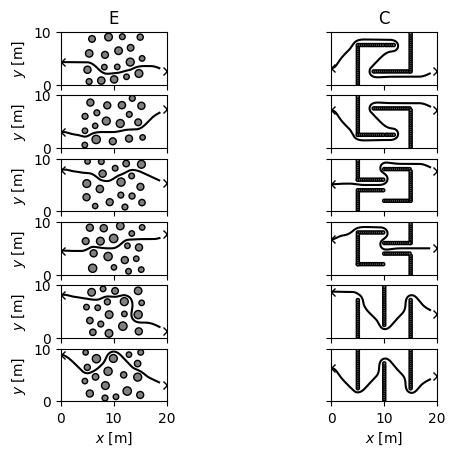

In [65]:
%matplotlib inline
from main import main
main(solution, plot=True, verbose=False)

Grade E: 6/6 cases passed.
Grade C: 6/6 cases passed.


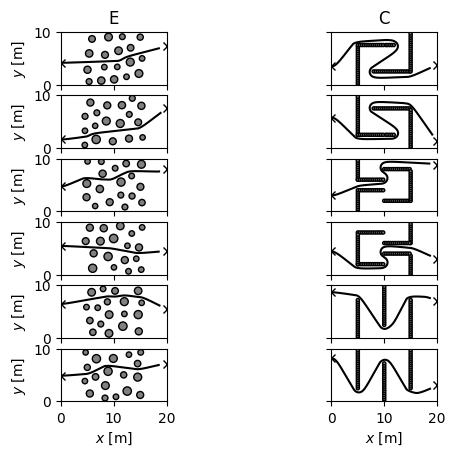

In [24]:
%matplotlib inline
from main import main
main(solution, plot=True, verbose=False)

Grade E: 0/6 cases passed.
Grade C: 0/6 cases passed.


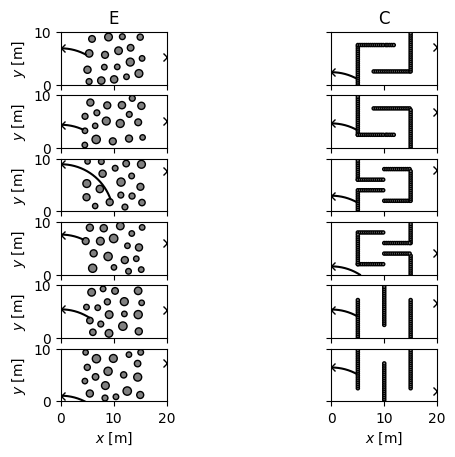

In [19]:
%matplotlib inline
from main import main
main(solution, plot=True, verbose=False)

Once you're done editing `solution.py`, you can also evaluate how well in the terminal by executing
- `python3 main.py`,
- `python3 main.py -p` for plotting,
- `python3 main.py -v` for step feedback,
- or `python3 main.py -p -v` for both.

**Note**: 
- you must install `matplotlib` for plotting to work,
- simulation is done at `dt=0.01` between `times[i]` and `times[i+1]`.

A succesful solution will generate something like this:
```bash
python3 main.py -p
```
```bash
Grade E: 6/6 cases passed.
Grade C: 6/6 cases passed.
```
![](plot.png)

# Useful resources
- [PythonRobotics](https://github.com/AtsushiSakai/PythonRobotics#path-planning) for planning algorithms,
- [demo.ipynb](demo.ipynb) for this assignment's introduction.